[2026-03-01 15:22:09] === 3銘柄をランダムに選択 ===
選択された3銘柄:
 - XRP
 - BNB
 - USDC
[2026-03-01 15:22:10] Fetching XRP ...
[2026-03-01 15:22:11] Fetching BNB ...
[2026-03-01 15:22:12] Fetching USDC ...


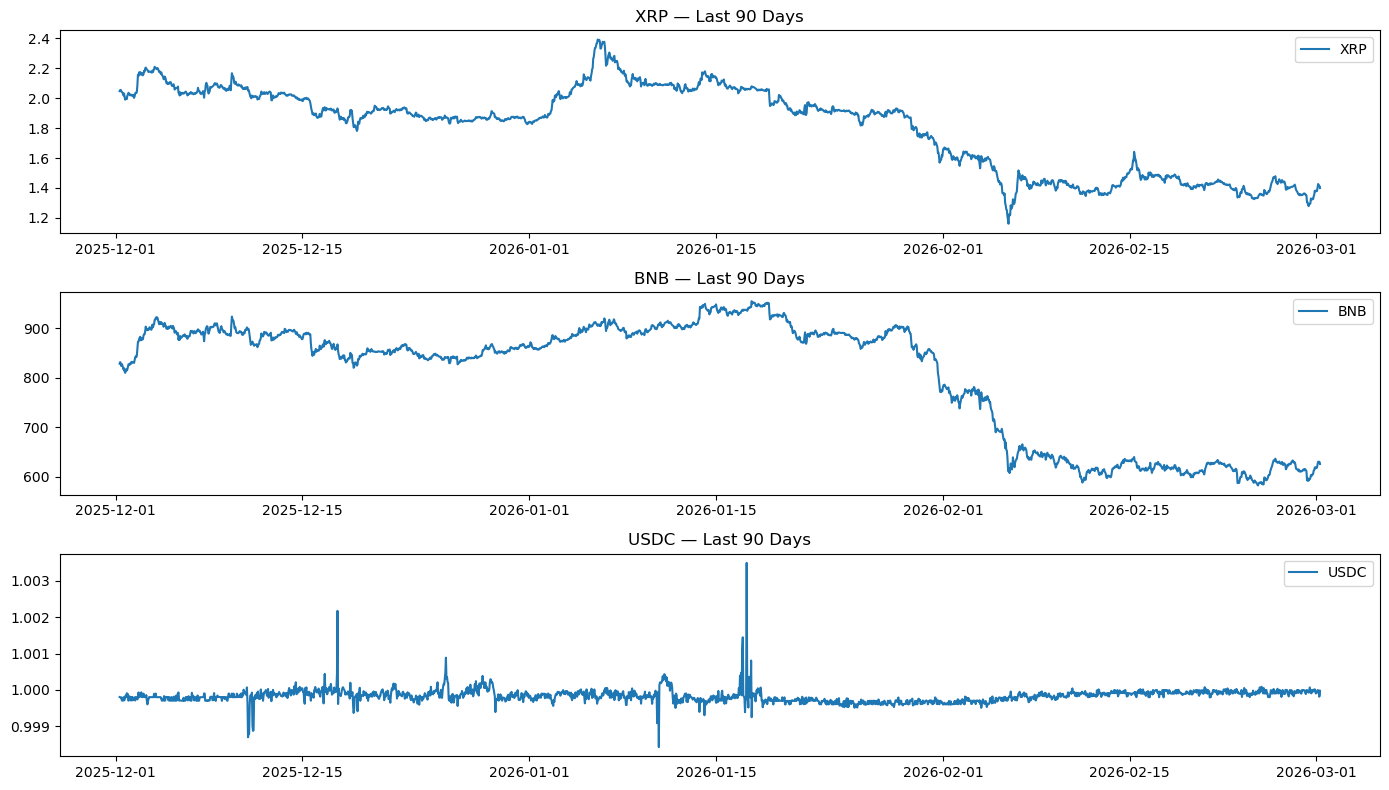

In [2]:
import random
from datetime import datetime
import time

import requests
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id, days=90, vs="usd"):
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.sort_values("timestamp")
    return df


# ------------------------
# メイン処理：3つ選択 → プロット
# ------------------------
def main():
    log("=== 3銘柄をランダムに選択 ===")

    selected = random.sample(COINS_POOL, 3)
    print("選択された3銘柄:")
    for _, sym in selected:
        print(" -", sym)

    # プロット準備
    plt.figure(figsize=(14, 8))

    for idx, (coin_id, symbol) in enumerate(selected, start=1):
        log(f"Fetching {symbol} ...")
        df = fetch_market_chart(coin_id, DAYS, VS)

        plt.subplot(3, 1, idx)
        plt.plot(df["timestamp"], df["price"], label=symbol)
        plt.title(f"{symbol} — Last {DAYS} Days")
        plt.legend()
        plt.tight_layout()

        time.sleep(0.5)

    plt.show()


if __name__ == "__main__":
    main()